In [335]:
import importlib
import pandas as pd
from src.A_Data_analysis import fleet_analysis
from src.A_Data_analysis import assignment_analysis
importlib.reload(fleet_analysis)
importlib.reload(assignment_analysis)

['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv', '', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Lib\\site-packages']


<module 'src.A_Data_analysis.assignment_analysis' from 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\src\\A_Data_analysis\\assignment_analysis.py'>

# Fleet model

In [7]:
db_full = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_treated_final_analysis.xlsx')
### Possibility to add filters on the aircraft size, aircraft model, etc...
db_selec = db_full[['Type','Engine', 'Delivery Date', 'Status', 'Date']].rename(columns={'Type':'Aircraft Type','Date':'Event Date'})


## Data analysis

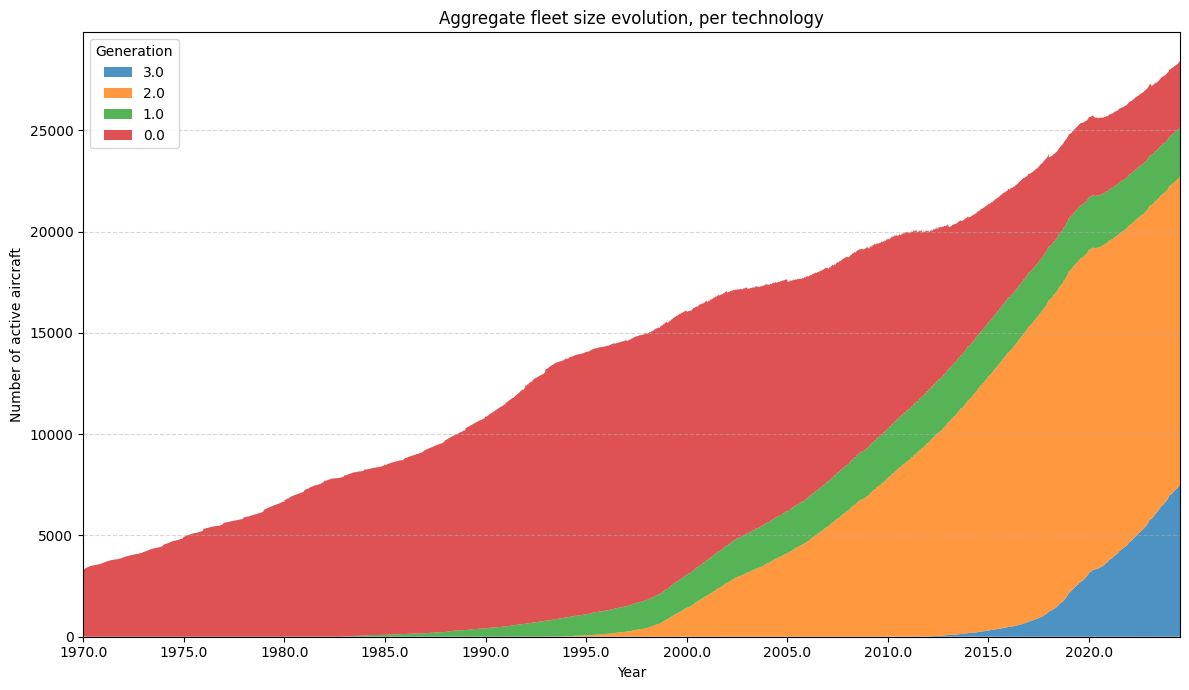

In [58]:
fleet_analysis.visu_fleet(db_selec)

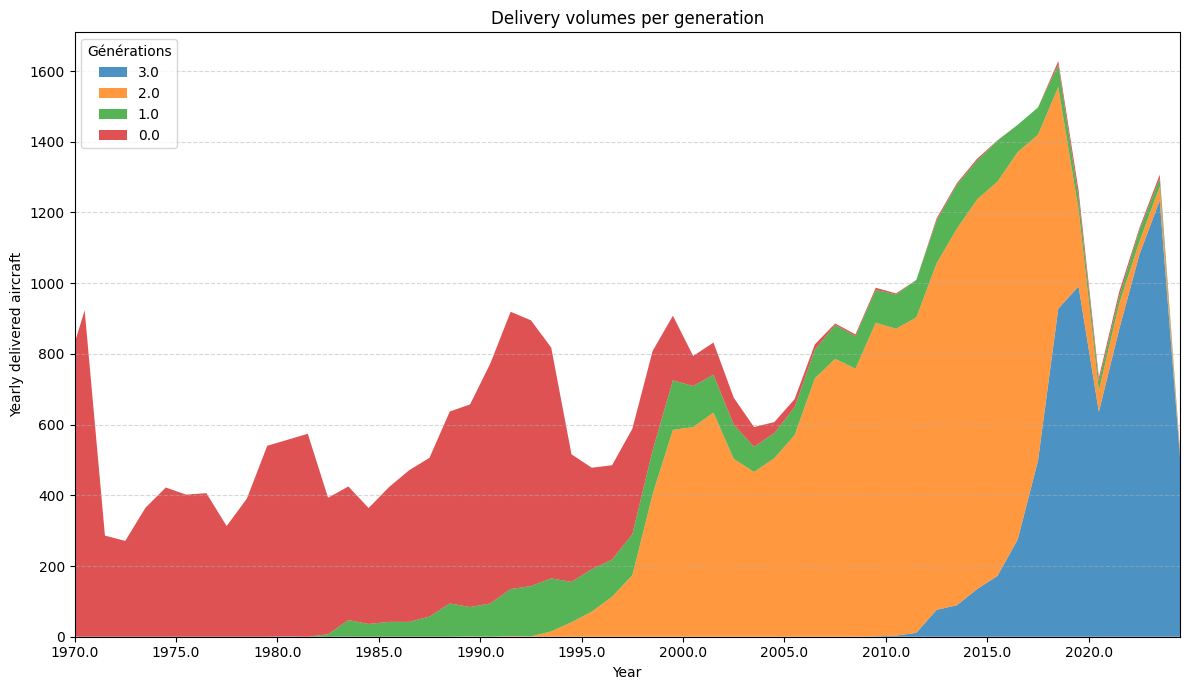

In [59]:
fleet_analysis.visu_prod(db_selec, reso = 1)

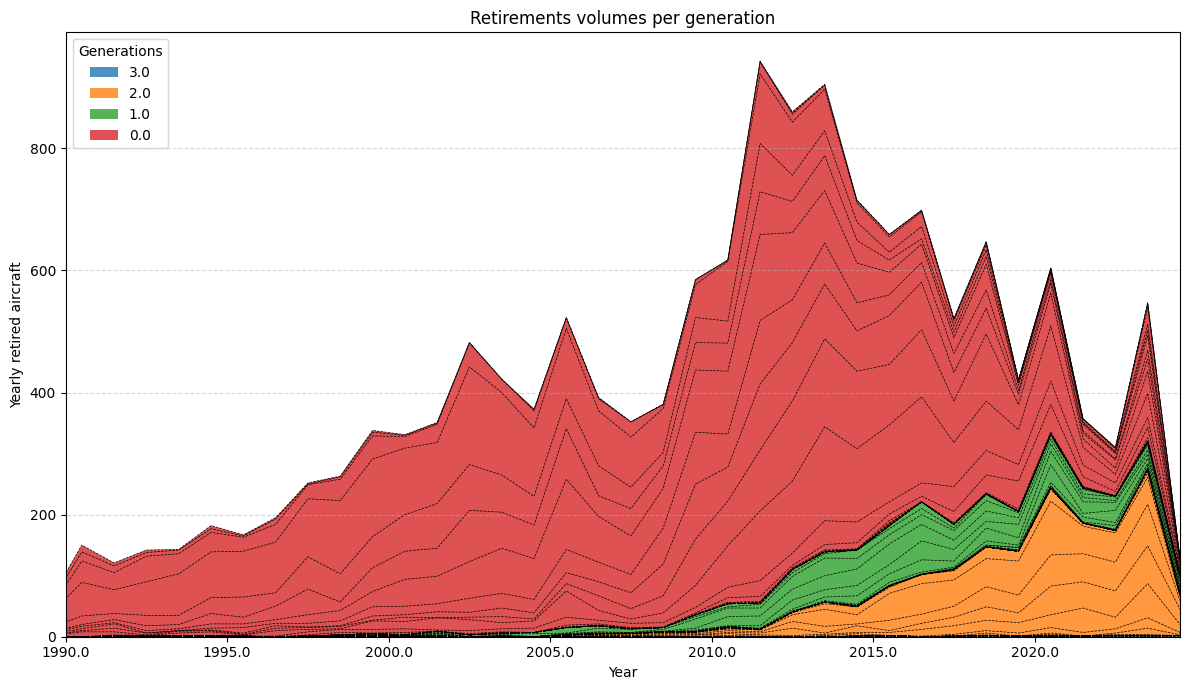

In [87]:
fleet_analysis.visu_retirements(db_selec, reso_1 = 1, reso_2 = 3)

## Model training

# Assignment model

In [154]:
traff_1 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Travail de Tobias\BTS Data ALL CARRIERS//' + str(1990) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
traff_1.rename(columns = {'ORIGIN_AIRPORT_ID' : 'ADEP','DEST_AIRPORT_ID': 'ADES', 'YEAR':'Period', 'DEPARTURES_PERFORMED': 'N_flights',
                          'AIRCRAFT_TYPE': 'Aircraft Type', 'SEATS': 'Seats'}, inplace = True)
traff_1 = traff_1[(traff_1['Seats']>0)]

print('a automatiser dans le module maybe')
distance_conn = (
    traff_1.groupby(['ADEP', 'ADES'])
    .apply(lambda x: (x['Seats'] * x['DISTANCE']).sum() / x['Seats'].sum())
    .reset_index()
    .rename(columns={0: 'Distance_conn (km)'})
)
seats_conn_p = (
    traff_1.groupby(['ADEP', 'ADES'])['Seats']
    .sum()
    .reset_index()
    .rename(columns={'Seats': 'Seats_conn_p'})
)
traff_1 = pd.merge(
    traff_1,
    distance_conn,
    on=['ADEP', 'ADES'],
    how='left'
)
traff_1 = pd.merge(
    traff_1,
    seats_conn_p,
    on=['ADEP', 'ADES'],
    how='left'
)

traff_1.drop(columns=['PASSENGERS', 'DISTANCE'], inplace = True)
traff_1['ASK_conn_p'] = traff_1['Seats_conn_p']*traff_1['Distance_conn (km)']
traff_1['ASK'] = traff_1['Seats']*traff_1['Distance_conn (km)']
traff_1['Aircraft Type Name'] = traff_1['Aircraft Type'] #a adapter bien sur
traff_1['ADEP Name'] = traff_1['ADEP'] #a adapter bien sur
traff_1['ADES Name'] = traff_1['ADES'] #a adapter bien sur

a automatiser dans le module maybe


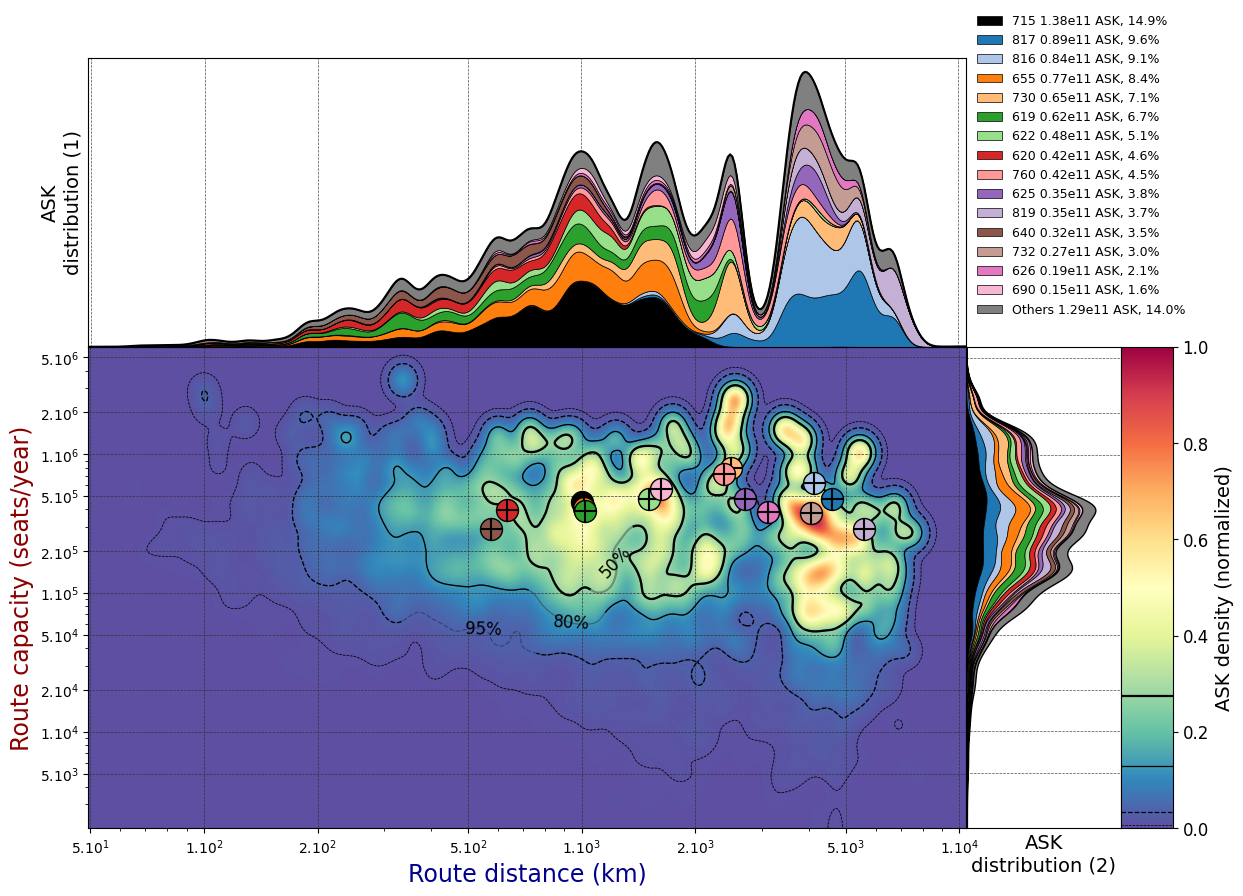

In [336]:
assignment_analysis.market_vis(traff_1, name_fig = 'test_market',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', Observation = 'ASK', Dist_limits = [0.49e2, 1.05e4], 
                                  Capac_limits = [2e3, 6e6], N_market = 15)

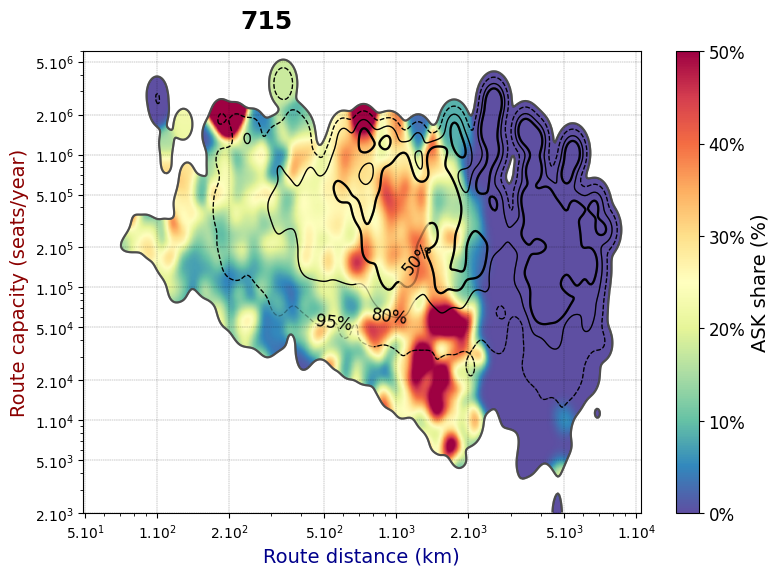

In [337]:
assignment_analysis.assign_vis(traff_1, [715], title_fig = '715', name_fig = 'test_assign',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', Observation = 'ASK', Dist_limits = [0.49e2, 1.05e4], 
                                  Capac_limits = [2e3, 6e6], vmax = 0.5)